<a href="https://colab.research.google.com/github/mukul-mschauhan/textanalytics/blob/master/Day01_NLP_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Day 01 — NLP Basics: From Raw Text to Features

---

## Dataset: Canva App Reviews (Google Play Store)

**Context:** Over 1,500 real user reviews of the Canva app — noisy, informal, and full of slang. Our goal is to build a **Sentiment Analysis model** that classifies each review as **Positive** or **Negative**.

**Key Columns:**
| Column | Description |
|---|---|
| `review` | Raw text written by the user |
| `score` | Star rating (1–5) |
| `Sentiment` | Target variable: Positive / Negative |
| `replyContent` | Canva's response (if any) |

---

## 🗺️ What We'll Cover Today
1. Setup & Load Data
2. Tokenization
3. Stopword Removal
4. Stemming (Porter, Snowball, Lancaster)
5. Lemmatization
6. Stemming vs. Lemmatization — Side-by-Side
7. POS Tags (Part-of-Speech)
8. NER Tags (Named Entity Recognition)
9. Text Cleaning Pipeline (putting it all together)
10. Bag of Words (BoW) vs. TF-IDF
11. Sentiment Model: BoW vs. TF-IDF Comparison

---
## ⚙️ Step 1: Setup — Install & Import Libraries

We install `spacy` for POS and NER tasks, and download the NLTK resources we need.
Everything else (pandas, sklearn, matplotlib) comes pre-installed in Colab.

In [1]:
# Install spaCy English model (run once)
!pip install -q spacy
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 29.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, WordNetLemmatizer

# spaCy
import spacy
from spacy import displacy
nlp = spacy.load('en_core_web_sm')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📂 Step 2: Load & Explore the Data

In [17]:
# Load data — update path if needed
canva = pd.read_excel('Day 01 Case Study Data - Canva_reviews.xlsx')

print(f'Shape: {canva.shape}')
canva[['review', 'score', 'Sentiment']].head(3)

Shape: (1500, 13)


,review,score,Sentiment
0,Overall it's really an amazing app. I've been ...,4,Negative
1,Hey! Yes I gave a 5 star rating... coz I belie...,5,Positive
2,Canva used to be a good app! But recently I've...,1,Negative


Sentiment
Positive    1032
Negative     468
Name: count, dtype: int64


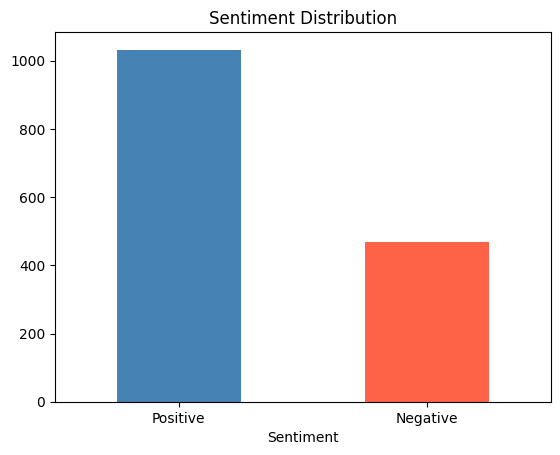

In [18]:
# Check sentiment distribution
print(canva['Sentiment'].value_counts())
canva['Sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], title='Sentiment Distribution')
plt.xticks(rotation=0)
plt.show()

---
## ✂️ Step 3: Tokenization

**What is it?**  
Tokenization splits raw text into individual units called **tokens** (words, punctuation, numbers).  
It is the **first step** in any NLP pipeline — you can't process text until it's broken down.

**Two common approaches:**
- `word_tokenize` — NLTK's default; handles contractions and punctuation intelligently.
- `RegexpTokenizer('[a-zA-Z0-9]+')` — keeps only alphanumeric tokens, discarding punctuation/symbols. Useful for noisy user-generated text like app reviews.

In [19]:
# Basic word tokenization
sentence = "Canva is amazing! But it's crashing a lot lately..."
tokens = word_tokenize(sentence)
print('word_tokenize:', tokens)

word_tokenize: ['Canva', 'is', 'amazing', '!', 'But', 'it', "'s", 'crashing', 'a', 'lot', 'lately', '...']


In [20]:
# Regex tokenizer — strips punctuation, keeps only words/numbers
# Pattern [a-zA-Z0-9]+ means: one or more letters or digits
regex_tokenizer = RegexpTokenizer('[a-zA-Z0-9]+')

sample_review = canva.loc[9, 'review']
print('📌 Raw Review:')
print(sample_review)
print()
print('✅ After Regex Tokenization:')
print(regex_tokenizer.tokenize(sample_review))

📌 Raw Review:
When I started trial everything works pretty well and so I decided to purchased every month and guess what! Every video I edited and saved was never been save at all even if how many times I tried, it was said was saved but when I check on my files it was not there, never been seen, and all pictures and caption is so blurred! And so I need to screenshoot and crop after so that I can use my edited design! What happen canva? So waste of moneyyyy!!!!!! I hope you can do solve this problem! Please

✅ After Regex Tokenization:
['When', 'I', 'started', 'trial', 'everything', 'works', 'pretty', 'well', 'and', 'so', 'I', 'decided', 'to', 'purchased', 'every', 'month', 'and', 'guess', 'what', 'Every', 'video', 'I', 'edited', 'and', 'saved', 'was', 'never', 'been', 'save', 'at', 'all', 'even', 'if', 'how', 'many', 'times', 'I', 'tried', 'it', 'was', 'said', 'was', 'saved', 'but', 'when', 'I', 'check', 'on', 'my', 'files', 'it', 'was', 'not', 'there', 'never', 'been', 'seen', 'and',

---
## 🛑 Step 4: Stopword Removal

**What are stopwords?**  
Common words like *"the", "is", "I", "a"* that appear everywhere and carry **no sentiment signal**.  
Removing them reduces vocabulary size and sharpens the model's focus on meaningful words.

> ⚠️ **Note:** Stopwords are context-dependent. The word *"not"* is a stopword by default but is critical for sentiment ("not good" ≠ "good"). Always review your stopword list.

In [21]:
stop_words = set(stopwords.words('english'))
regex_tokenizer = RegexpTokenizer('[a-zA-Z0-9]+')

sample_tokens = regex_tokenizer.tokenize(sample_review)

# Keep only tokens NOT in stopword list, also lowercase everything
filtered_tokens = [t.lower() for t in sample_tokens if t.lower() not in stop_words]

print(f'Before stopword removal: {len(sample_tokens)} tokens')
print(f'After stopword removal:  {len(filtered_tokens)} tokens')
print()
print('Filtered tokens:', filtered_tokens)

Before stopword removal: 98 tokens
After stopword removal:  44 tokens

Filtered tokens: ['started', 'trial', 'everything', 'works', 'pretty', 'well', 'decided', 'purchased', 'every', 'month', 'guess', 'every', 'video', 'edited', 'saved', 'never', 'save', 'even', 'many', 'times', 'tried', 'said', 'saved', 'check', 'files', 'never', 'seen', 'pictures', 'caption', 'blurred', 'need', 'screenshoot', 'crop', 'use', 'edited', 'design', 'happen', 'canva', 'waste', 'moneyyyy', 'hope', 'solve', 'problem', 'please']


---
## 🌿 Step 5: Stemming

**What is stemming?**  
Stemming chops off word endings using **rules**, reducing a word to its base/root form.  
It is **fast but crude** — the result may not be a real dictionary word.

**Three stemmers available in NLTK:**

| Stemmer | Style | Speed | Accuracy | Example: "caring" |
|---|---|---|---|---|
| **Porter** | Moderate | Fast | Good | `care` |
| **Snowball** (Porter2) | Moderate | Fast | Better than Porter | `care` |
| **Lancaster** | Aggressive | Fastest | Lossy | `car` |

> 💡 **Rule of thumb:** Use **Snowball** for most English NLP tasks. Avoid Lancaster when readability matters.

In [6]:
porter   = PorterStemmer()
snowball = SnowballStemmer('english')
lancaster = LancasterStemmer()

# Test on a few illustrative words
test_words = ['caring', 'happily', 'running', 'studies', 'purchased']

print(f"{'Word':<15} {'Porter':<15} {'Snowball':<15} {'Lancaster':<15}")
print('-' * 60)
for w in test_words:
    print(f"{w:<15} {porter.stem(w):<15} {snowball.stem(w):<15} {lancaster.stem(w):<15}")

Word            Porter          Snowball        Lancaster      
------------------------------------------------------------
caring          care            care            car            
happily         happili         happili         happy          
running         run             run             run            
studies         studi           studi           study          
purchased       purchas         purchas         purchas        


**Key observation:**  
- `happily` → Porter/Snowball give `happili` (not a real word), Lancaster gives `happy` (more readable but coincidence).
- `studies` → Porter/Snowball give `studi` (not real), Lancaster gives `study`.
- **Stemmers sacrifice correctness for speed.** This is why Lemmatization is preferred when you need proper words.

---
## 📖 Step 6: Lemmatization

**What is lemmatization?**  
Lemmatization reduces a word to its **dictionary base form (lemma)** using vocabulary and grammar rules.  
Unlike stemming, the output is **always a real word**.

**Key insight: POS matters!**  
The lemma of a word depends on its part of speech:
- `running` as a **verb** → `run`
- `running` as a **noun** → `running` (unchanged)
- `better` as an **adjective** → `good`

If you don't specify POS, the lemmatizer defaults to **noun**, which is why some words don't change.

In [7]:
lemmatizer = WordNetLemmatizer()

# Without POS — defaults to noun
words_no_pos = ['running', 'better', 'cats', 'geese', 'studies']
print('Without POS tag (defaults to noun):')
for w in words_no_pos:
    print(f'  {w:15} → {lemmatizer.lemmatize(w)}')

print()

# With correct POS — much better results
print('With correct POS tag:')
print(f'  running (v)  → {lemmatizer.lemmatize("running", pos="v")}')
print(f'  better  (a)  → {lemmatizer.lemmatize("better",  pos="a")}')
print(f'  studies (v)  → {lemmatizer.lemmatize("studies", pos="v")}')

Without POS tag (defaults to noun):
  running         → running
  better          → better
  cats            → cat
  geese           → goose
  studies         → study

With correct POS tag:
  running (v)  → run
  better  (a)  → good
  studies (v)  → study


---
## ⚔️ Step 7: Stemming vs. Lemmatization — Side-by-Side

Let's directly compare both on the same set of words so you can see the difference clearly.

In [8]:
compare_words = ['Playing', 'Caring', 'Studies', 'Leaves', 'Children', 'happily', 'better']

print(f"{'Word':<15} {'Snowball Stem':<20} {'Lemma (noun)':<20} {'Lemma (verb)':<20}")
print('-' * 75)
for w in compare_words:
    stem  = snowball.stem(w)
    lemma_n = lemmatizer.lemmatize(w.lower(), pos='n')
    lemma_v = lemmatizer.lemmatize(w.lower(), pos='v')
    print(f"{w:<15} {stem:<20} {lemma_n:<20} {lemma_v:<20}")

Word            Snowball Stem        Lemma (noun)         Lemma (verb)        
---------------------------------------------------------------------------
Playing         play                 playing              play                
Caring          care                 caring               care                
Studies         studi                study                study               
Leaves          leav                 leaf                 leave               
Children        children             child                children            
happily         happili              happily              happily             
better          better               better               better              


**Summary: Stemming vs. Lemmatization**

| | Stemming | Lemmatization |
|---|---|---|
| Method | Rule-based suffix stripping | Dictionary + grammar lookup |
| Output | May not be a real word | Always a real dictionary word |
| Speed | Very fast | Slower |
| Accuracy | Lower | Higher |
| Best for | Large-scale IR, search indexing | NLP tasks needing readability (sentiment, QA) |

> 🎯 **For Canva Sentiment Analysis:** Use **Lemmatization** — we want clean, meaningful features.

---
## 🏷️ Step 8: POS Tags (Part-of-Speech Tagging)

**What is POS tagging?**  
POS tagging assigns a **grammatical role** to every word in a sentence — noun, verb, adjective, adverb, etc.

**Why does it matter?**
- Same word, different meaning: *"I **book** a flight"* (book = VERB) vs. *"I read a **book**"* (book = NOUN)
- Helps downstream tasks like lemmatization, dependency parsing, and information extraction
- Filters to only nouns/adjectives for topic modelling or aspect-based sentiment

**Common spaCy POS tags:**
| Tag | Meaning | Example |
|---|---|---|
| `NOUN` | Noun | *app, design* |
| `VERB` | Verb | *crashed, saved* |
| `ADJ` | Adjective | *amazing, blurred* |
| `ADV` | Adverb | *really, never* |
| `PROPN` | Proper Noun | *Canva, Google* |
| `INTJ` | Interjection | *please, wow* |

> 📖 Full tag reference: https://universaldependencies.org/u/pos/

In [9]:
# POS tags on a simple sentence
doc = nlp('The app crashed when I tried to save my design yesterday.')

print(f"{'Token':<15} {'POS':<10} {'Explanation'}")
print('-' * 50)
for token in doc:
    print(f"{token.text:<15} {token.pos_:<10} {spacy.explain(token.pos_)}")

Token           POS        Explanation
--------------------------------------------------
The             DET        determiner
app             NOUN       noun
crashed         VERB       verb
when            SCONJ      subordinating conjunction
I               PRON       pronoun
tried           VERB       verb
to              PART       particle
save            VERB       verb
my              PRON       pronoun
design          NOUN       noun
yesterday       NOUN       noun
.               PUNCT      punctuation


In [10]:
# Visualise dependency tree (how words relate to each other)
doc = nlp('Time flies like an arrow')
displacy.render(doc, style='dep', jupyter=True)

In [11]:
# POS + Lemma combined — this shows spaCy's lemmatizer in action
# Notice: spaCy uses POS context automatically for lemmatization (better than NLTK's WordNetLemmatizer alone)
doc = nlp('I tried saving the edited design but it crashed and I lost everything.')

print(f"{'Token':<15} {'POS':<8} {'Lemma':<15}")
print('-' * 40)
for token in doc:
    print(f"{token.text:<15} {token.pos_:<8} {token.lemma_:<15}")

Token           POS      Lemma          
----------------------------------------
I               PRON     I              
tried           VERB     try            
saving          VERB     save           
the             DET      the            
edited          VERB     edit           
design          NOUN     design         
but             CCONJ    but            
it              PRON     it             
crashed         VERB     crash          
and             CCONJ    and            
I               PRON     I              
lost            VERB     lose           
everything      PRON     everything     
.               PUNCT    .              


---
## 🔍 Step 9: NER Tags (Named Entity Recognition)

**What is NER?**  
NER identifies and classifies **real-world entities** in text — people, places, organisations, dates, money, etc.

**Why does it matter for Canva reviews?**
- Identify if users mention **specific features** ("Canva Pro") vs general complaints
- Extract **dates** to see if issues spike after an app update
- Spot **competing brands** users mention

**Common NER labels:**
| Label | Meaning | Example |
|---|---|---|
| `PERSON` | People's names | *Bill Gates* |
| `ORG` | Companies, organisations | *Google, Canva* |
| `GPE` | Country, city, state | *India, Mumbai* |
| `DATE` | Dates and time periods | *last month, June 2021* |
| `MONEY` | Monetary values | *$9.99* |
| `PRODUCT` | Products, apps | *Canva Pro* |

In [12]:
# Classic example — well-known entities
doc = nlp('Sundar Pichai became CEO of Google in 2015 in Mountain View, California.')
displacy.render(doc, style='ent', jupyter=True)

In [13]:
# Real Canva review — see what NER finds
canva_review = nlp('I subscribed to Canva Pro last June for $12.99 but the app stopped working after the latest update.')
displacy.render(canva_review, style='ent', jupyter=True)

In [14]:
# Where NER struggles: domain-specific / Indian brands
# spaCy's en_core_web_sm is trained on English news — it won't know 'Haldirams' is a brand
doc2 = nlp('Haldirams was founded by Mr. Haldiram in Bikaner, Rajasthan.')
displacy.render(doc2, style='ent', jupyter=True)

**Key Insight:** Pre-trained NER models work well for general English but may **miss domain-specific entities** (Indian brands, app feature names, product jargon). In such cases, you need to **fine-tune** the NER model with your own labelled examples.

In [22]:
# Programmatic NER — loop through entities from all reviews
# Let's find the most commonly mentioned entities in Canva reviews
from collections import Counter

entity_list = []
for review in canva['review'].dropna()[:200]:   # sample 200 reviews for speed
    doc = nlp(str(review))
    for ent in doc.ents:
        entity_list.append((ent.text, ent.label_))

top_entities = Counter(entity_list).most_common(15)
print(f"{'Entity':<30} {'Label':<15} {'Count'}")
print('-' * 55)
for (text, label), count in top_entities:
    print(f"{text:<30} {label:<15} {count}")

Entity                         Label           Count
-------------------------------------------------------
Canva                          ORG             17
first                          ORDINAL         10
Canva                          PERSON          6
one                            CARDINAL        5
4                              CARDINAL        4
One                            CARDINAL        4
8                              CARDINAL        3
5                              CARDINAL        2
10                             CARDINAL        2
2                              CARDINAL        2
App                            PERSON          2
YouTube                        PRODUCT         2
Android                        ORG             2
the past 5 years               DATE            1
mobile apps                    PERSON          1


---
## 🧹 Step 10: Text Cleaning Pipeline

Now we combine everything into a **single reusable function** that:
1. Regex tokenizes (removes punctuation & symbols)
2. Lowercases all tokens
3. Removes stopwords
4. Lemmatizes (using WordNetLemmatizer)
5. Removes short tokens (length < 2)
6. Applies a custom mapping for noisy slang (e.g., `moneyyy` → `money`)

This is the **feature engineering** step before we feed text to a model.

In [23]:
# Custom slang/typo corrections for this dataset
CUSTOM_MAP = {
    'moneyyy': 'money', 'moneyyyy': 'money', 'moneyyyi': 'money',
    'ooohhhh': 'oh', 'yesss': 'yes', 'plsss': 'please',
    'canva': 'canva'  # keep brand name as-is
}

regex_tok = RegexpTokenizer('[a-zA-Z0-9]+')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Full NLP preprocessing pipeline:
    Tokenize → Lowercase → Remove Stopwords → Lemmatize → Filter short tokens
    Returns a list of clean tokens.
    """
    tokens = regex_tok.tokenize(str(text).lower())        # Step 1: Tokenize + lowercase
    tokens = [t for t in tokens if t not in stop_words]   # Step 2: Remove stopwords
    tokens = [CUSTOM_MAP.get(t, t) for t in tokens]       # Step 3: Fix slang
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # Step 4: Lemmatize
    tokens = [t for t in tokens if len(t) > 2]            # Step 5: Remove very short tokens
    return tokens

# Test on review #9 from the dataset
print('📌 Original:')
print(canva.loc[9, 'review'])
print()
print('✅ Cleaned tokens:')
print(clean_text(canva.loc[9, 'review']))

📌 Original:
When I started trial everything works pretty well and so I decided to purchased every month and guess what! Every video I edited and saved was never been save at all even if how many times I tried, it was said was saved but when I check on my files it was not there, never been seen, and all pictures and caption is so blurred! And so I need to screenshoot and crop after so that I can use my edited design! What happen canva? So waste of moneyyyy!!!!!! I hope you can do solve this problem! Please

✅ Cleaned tokens:
['started', 'trial', 'everything', 'work', 'pretty', 'well', 'decided', 'purchased', 'every', 'month', 'guess', 'every', 'video', 'edited', 'saved', 'never', 'save', 'even', 'many', 'time', 'tried', 'said', 'saved', 'check', 'file', 'never', 'seen', 'picture', 'caption', 'blurred', 'need', 'screenshoot', 'crop', 'use', 'edited', 'design', 'happen', 'canva', 'waste', 'money', 'hope', 'solve', 'problem', 'please']


In [24]:
# Apply pipeline to entire dataset
# Join tokens back into a string (required by sklearn vectorizers)
canva['text_clean'] = canva['review'].apply(lambda x: ' '.join(clean_text(x)))

# Encode target: Negative = 1, Positive = 0
canva['Sentiment'] = canva['Sentiment'].apply(lambda x: 1 if x == 'Negative' else 0)

print(f'Clean text sample:\n{canva["text_clean"].iloc[0]}')

Clean text sample:
overall really amazing app using past year however one issue though wanted get address since think issue lasted many year text blurred zoom pixelated thought issue occurs mobile apps however also present website please fix still remember time export high definition text love experience thank


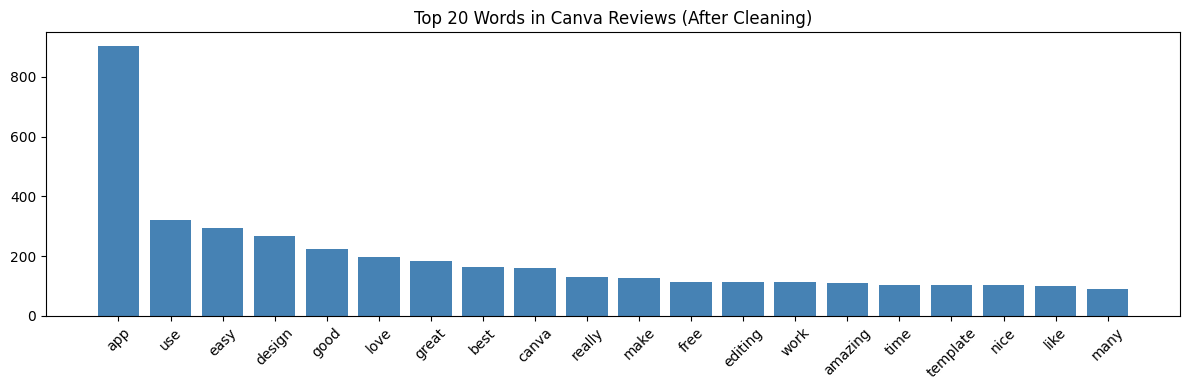

In [25]:
# Top 20 most frequent words after cleaning
from collections import Counter

all_words = ' '.join(canva['text_clean']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 Words in Canva Reviews (After Cleaning)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

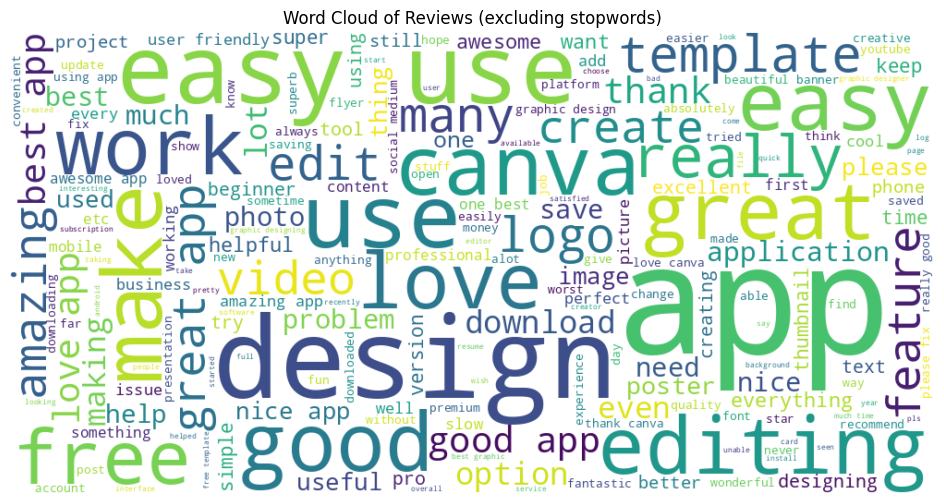

In [28]:
from wordcloud import WordCloud


# Generate a word cloud
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(12, 6))

# In image processing, interpolation refers to the method used to estimate the values of pixels at non-integer coordinates.
# When displaying an image, interpolation determines how intermediate pixels are calculated
# when resizing or transforming the image.

plt.imshow(wordcloud, interpolation='bilinear')

plt.title('Word Cloud of Reviews (excluding stopwords)')
plt.axis('off')
plt.show()

---
## 📊 Step 11: Bag of Words (BoW) vs. TF-IDF

Machine learning models can't process raw text — they need **numbers**.  
Both BoW and TF-IDF convert text into numerical feature vectors. But they do it differently.

---

### 🛍️ Bag of Words (BoW)

**Concept:**  
Create a vocabulary of all unique words in the corpus. For each document, represent it as a vector where each position = a word, and the value = how many times that word appears (or just 1/0 if using `binary=True`).

**Example:**
```
Doc 1: "the app is amazing"
Doc 2: "the app keeps crashing"

Vocabulary: [amazing, app, crashing, is, keeps, the]
Doc 1 vector: [1, 1, 0, 1, 0, 1]
Doc 2 vector: [0, 1, 1, 0, 1, 1]
```

**Problems with BoW:**
- Common words like *"the", "app"* appear in almost every review — they dominate the vector but carry little signal.
- Two reviews that both say *"the app is good"* and *"the app"* look more similar than they should.
- No sense of word **importance** — all words are treated equally.

---

### 📐 TF-IDF (Term Frequency × Inverse Document Frequency)

**Concept:**  
TF-IDF assigns a **weight** to each word based on two factors:

- **TF (Term Frequency):** How often does this word appear in *this* document?
  `TF = count of word in doc / total words in doc`

- **IDF (Inverse Document Frequency):** How *rare* is this word across *all* documents?
  `IDF = log(total docs / docs containing this word)`

- **TF-IDF Score = TF × IDF**

**What this means:**
- A word like *"app"* appears in 1,400/1,500 reviews → low IDF → low TF-IDF score → not important
- A word like *"crashing"* appears in 80 reviews → high IDF → high TF-IDF score → very informative

**TF-IDF rewards words that are frequent in a document but rare across the corpus.**

---

### BoW vs. TF-IDF — At a Glance

| | Bag of Words | TF-IDF |
|---|---|---|
| What it captures | Word presence/count | Word importance/relevance |
| Common words | Over-weighted | Down-weighted by IDF |
| Rare but meaningful words | Under-weighted | Up-weighted |
| Output values | Integer counts (or binary) | Decimal weights (0–1) |
| Best for | Simple baselines, short texts | Most NLP classification tasks |

> 🏆 **Which is better?**  
> TF-IDF is almost always better for text classification because it removes the noise of high-frequency words and highlights the terms that truly distinguish one document from another.  
> **Use BoW** when you have very short texts (like tweets) or need interpretability.  
> **Use TF-IDF** as your default for review analysis, spam detection, topic modelling, etc.

In [29]:
# Mini illustration: BoW vs TF-IDF on 3 sentences
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

mini_corpus = [
    'the app is amazing and easy to use',
    'the app keeps crashing every time I use it',
    'the app crashed and I lost all my designs'
]

# BoW
bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(mini_corpus).toarray()

# TF-IDF
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(mini_corpus).toarray()

print('=== Bag of Words ===')
bow_df = pd.DataFrame(bow_matrix, columns=bow_vec.get_feature_names_out())
print(bow_df.round(3))

print()
print('=== TF-IDF ===')
tfidf_df = pd.DataFrame(tfidf_matrix, columns=tfidf_vec.get_feature_names_out())
print(tfidf_df.round(3))

=== Bag of Words ===
   all  amazing  and  app  crashed  crashing  designs  easy  every  is  it  \
0    0        1    1    1        0         0        0     1      0   1   0   
1    0        0    0    1        0         1        0     0      1   0   1   
2    1        0    1    1        1         0        1     0      0   0   0   

   keeps  lost  my  the  time  to  use  
0      0     0   0    1     0   1    1  
1      1     0   0    1     1   0    1  
2      0     1   1    1     0   0    0  

=== TF-IDF ===
     all  amazing    and    app  crashed  crashing  designs   easy  every  \
0  0.000    0.413  0.314  0.244    0.000     0.000    0.000  0.413  0.000   
1  0.000    0.000  0.000  0.236    0.000     0.399    0.000  0.000  0.399   
2  0.399    0.000  0.304  0.236    0.399     0.000    0.399  0.000  0.000   

      is     it  keeps   lost     my    the   time     to    use  
0  0.413  0.000  0.000  0.000  0.000  0.244  0.000  0.413  0.314  
1  0.000  0.399  0.399  0.000  0.000  0.236

**Observe:**  
The word `the` gets a count of 1 in BoW for all 3 documents — it adds no discrimination.  
In TF-IDF, `crashing` gets a higher score in Doc 2 where it appears and is rare — this is the discriminative signal we want.

---
## 🤖 Step 12: Sentiment Model — BoW vs. TF-IDF

Let's now train a Logistic Regression classifier using both vectorisation methods and compare results.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train/test split ONCE — same split for fair comparison
X = canva['text_clean']
y = canva['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [31]:
# ─── MODEL 1: Bag of Words ───
# binary=True means: 1 if word present, 0 if not (ignores count)
# min_df=5: ignore words appearing in fewer than 5 reviews
bow_vectorizer = CountVectorizer(binary=True, min_df=5, stop_words='english')
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
pred_bow = lr_bow.predict(X_test_bow)

print('=== Bag of Words + Logistic Regression ===')
print(classification_report(y_test, pred_bow, target_names=['Positive', 'Negative']))

=== Bag of Words + Logistic Regression ===
              precision    recall  f1-score   support

    Positive       0.90      0.94      0.92       216
    Negative       0.82      0.73      0.77        84

    accuracy                           0.88       300
   macro avg       0.86      0.83      0.85       300
weighted avg       0.88      0.88      0.88       300



In [32]:
# ─── MODEL 2: TF-IDF ───
# min_df=5: same threshold for fair comparison
tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print('=== TF-IDF + Logistic Regression ===')
print(classification_report(y_test, pred_tfidf, target_names=['Positive', 'Negative']))

=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

    Positive       0.90      0.95      0.92       216
    Negative       0.85      0.73      0.78        84

    accuracy                           0.89       300
   macro avg       0.87      0.84      0.85       300
weighted avg       0.88      0.89      0.88       300



In [33]:
# Side-by-side accuracy comparison
print('──────────────────────────────────────────')
print(f"  BoW  Accuracy:   {accuracy_score(y_test, pred_bow):.4f}")
print(f"  TF-IDF Accuracy: {accuracy_score(y_test, pred_tfidf):.4f}")
print('──────────────────────────────────────────')
print("\n💡 TF-IDF typically performs better (or on par) for classification.")
print("   The advantage is more visible when data is unbalanced or vocabulary is large.")

──────────────────────────────────────────
  BoW  Accuracy:   0.8800
  TF-IDF Accuracy: 0.8867
──────────────────────────────────────────

💡 TF-IDF typically performs better (or on par) for classification.
   The advantage is more visible when data is unbalanced or vocabulary is large.


---
## ✅ Session Summary

| Concept | What it does | When to use |
|---|---|---|
| **Tokenization** | Splits text into tokens | Always — first step |
| **Stopword Removal** | Removes noise words | Almost always; review list for sentiment tasks |
| **Stemming** | Fast root form (may not be real word) | Search engines, IR tasks, speed-critical pipelines |
| **Lemmatization** | Proper dictionary form | Sentiment analysis, QA, summarisation |
| **POS Tags** | Grammatical role of each word | Parsing, improved lemmatisation, feature engineering |
| **NER Tags** | Extracts entities (person, org, date) | Information extraction, knowledge graphs |
| **Bag of Words** | Word presence/count vector | Simple baseline; short texts |
| **TF-IDF** | Weighted by word rarity | Most classification tasks; better than BoW in practice |

---

### 🚀 What's Next?
- **Day 02:** Word Embeddings — Word2Vec, GloVe (fixed vectors)
- **Day 03:** Contextual Embeddings — BERT, transformers (position-aware vectors)
- **Day 04:** Building a full Sentiment Analysis pipeline with transformer fine-tuning